In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/stock_news_11_columns_6000rows.csv")

print(df.head())
print(df.shape)

         Date    Symbol       Open       High        Low      Close    Volume  \
0  2014-06-17  ADANIENT  66.547213  68.372835  65.595632  68.090887  15536814   
1  2014-06-20  ADANIENT  64.802560  64.943129  62.834586  63.122749  18656578   
2  2014-07-30  ADANIENT  61.195763  62.305072  61.167500  62.163759   9157887   
3  2014-07-31  ADANIENT  63.051689  64.038560  62.115245  62.497030  10848470   
4  2014-08-01  ADANIENT  61.751109  62.276071  60.276908  60.478262  10785441   

                                       News_Headline  Sentiment_Score  \
0  Australia Delays Decision On Adani's $15B Coal...             -1.0   
1  Australia Delays Decision On Adani's $15B Coal...             -1.0   
2  Robyn Lawley’s naked protest against Adani Gro...              0.0   
3  Robyn Lawley’s naked protest against Adani Gro...              0.0   
4  Robyn Lawley’s naked protest against Adani Gro...              0.0   

   Volatility  Target  
0    0.027382       0  
1    0.027355       0  
2 

In [ ]:
df.describe()

,Open,High,Low,Close,Volume,Sentiment_Score,Volatility,Target
count,6000.000000,6000.000000,6000.000000,6000.000000,6.000000e+03,6000.000000,6000.000000,6000.000000
mean,1511.404968,1528.551786,1491.977887,1510.353003,8.543745e+06,0.000262,0.018022,0.540833
std,1851.872915,1871.224097,1829.947753,1850.680107,1.814969e+07,0.633447,0.009489,0.498371
min,8.261796,8.425484,8.140351,8.293478,1.000000e+00,-1.000000,0.003461,0.000000
25%,313.907633,319.260986,308.844618,314.072100,1.253829e+06,0.000000,0.012414,0.000000
50%,881.594525,891.514537,870.110932,882.416965,3.279215e+06,0.000000,0.015900,1.000000
75%,1892.552213,1919.088815,1865.592074,1890.897074,8.779442e+06,0.000000,0.020885,1.000000
max,13380.483590,13539.104149,13271.954196,13493.062027,2.815185e+08,1.000000,0.118655,1.000000


In [ ]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

print(df["Date"].isnull().sum())

0


In [ ]:
df.shape


(6000, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             6000 non-null   datetime64[ns]
 1   Symbol           6000 non-null   object        
 2   Open             6000 non-null   float64       
 3   High             6000 non-null   float64       
 4   Low              6000 non-null   float64       
 5   Close            6000 non-null   float64       
 6   Volume           6000 non-null   int64         
 7   News_Headline    6000 non-null   object        
 8   Sentiment_Score  6000 non-null   float64       
 9   Volatility       6000 non-null   float64       
 10  Target           6000 non-null   int64         
dtypes: datetime64[ns](1), float64(6), int64(2), object(2)
memory usage: 515.8+ KB


In [ ]:
df.isnull().sum()

,0
Date,0
Symbol,0
Open,0
High,0
Low,0
Close,0
Volume,0
News_Headline,0
Sentiment_Score,0
Volatility,0


In [ ]:
df.isna().sum()

,0
Date,0
Symbol,0
Open,0
High,0
Low,0
Close,0
Volume,0
News_Headline,0
Sentiment_Score,0
Volatility,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print('Number of columns:', len(df.columns))
print("columns",df.columns)

Number of columns: 11
columns Index(['Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Volume',
       'News_Headline', 'Sentiment_Score', 'Volatility', 'Target'],
      dtype='object')


In [ ]:
print(df["Sentiment_Score"].dtype)

float64


**handling outliers**

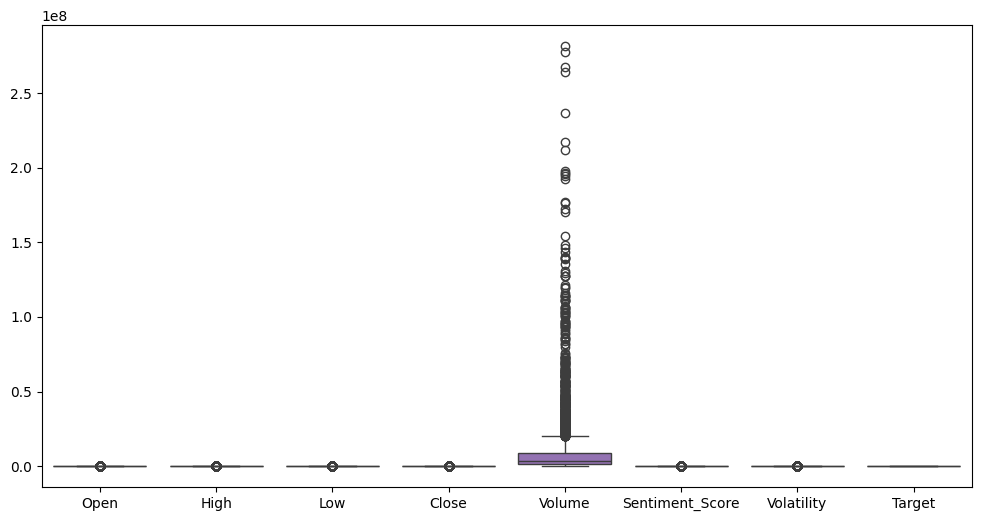

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(df)
plt.show()

<Axes: ylabel='Volume'>

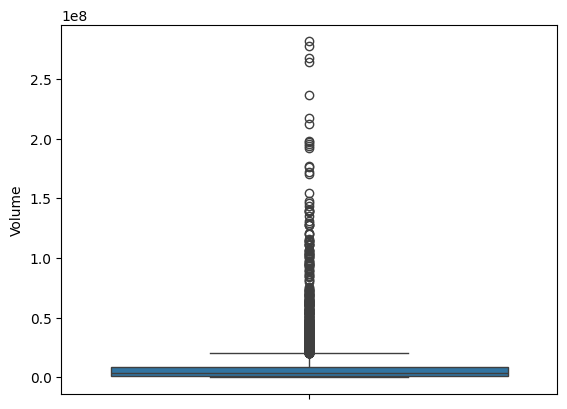

In [ ]:
sns.boxplot(df["Volume"])

In [ ]:


# Find Q1 and Q3
q1, q3 = np.percentile(df["Volume"], [25, 75])

print("Q1:", q1)
print("Q3:", q3)

# Calculate IQR
IQR = q3 - q1
print("IQR:", IQR)

# Calculate limits
lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

# Check outliers
outlier = []

for i in df["Volume"]:
    if i < lower_limit or i > upper_limit:
        outlier.append(i)

print("Number of Outliers:", len(outlier))
print("Outliers:", outlier)

Q1: 1253828.75
Q3: 8779442.0
IQR: 7525613.25
Lower Limit: -10034591.125
Upper Limit: 20067861.875
Number of Outliers: 531
Outliers: [47768017, 47788495, 69112255, 29061368, 28416613, 25180264, 40223353, 53117263, 23301663, 59068541, 44372635, 22879047, 44037512, 23225426, 26734971, 26498553, 22590223, 22234466, 28863244, 34925418, 23499658, 29995867, 65029268, 22718970, 21193407, 27376180, 26227230, 24743877, 68164983, 79550024, 33993771, 22154649, 20093405, 20587200, 20470221, 60588570, 21568303, 26284445, 30269397, 21329897, 46669959, 24786934, 25935098, 24813369, 40605116, 22584636, 22379982, 27130743, 20541108, 57250280, 20274863, 22998861, 23381671, 40105192, 64764700, 36269848, 24771251, 22160754, 22057816, 22003475, 24409869, 26151798, 20699731, 30410085, 26166860, 29450050, 28329780, 20267564, 22787147, 22571059, 25721293, 30705546, 53570688, 86589956, 20589548, 28949452, 22826224, 26344571, 24171342, 28353642, 25751894, 21949035, 25498854, 21067820, 21114784, 24436379, 1942070

In [ ]:
df['Volume'] = np.where(df["Volume"] > upper_limit, upper_limit, df["Volume"])


In [ ]:

# Q1 and Q3
q1, q3 = np.percentile(df["Open"], [25, 75])

print("Q1:", q1)
print("Q3:", q3)

# IQR
IQR = q3 - q1
print("IQR:", IQR)

# Lower and Upper limits
lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

# Find outliers
outlier = []

for i in df["Open"]:
    if i < lower_limit or i > upper_limit:
        outlier.append(i)



Q1: 313.9076334570951
Q3: 1892.5522133856953
IQR: 1578.6445799286003
Lower Limit: -2054.0592364358054
Upper Limit: 4260.519083278596


In [ ]:
df["Open"] = np.where(df["Open"] > upper_limit, upper_limit, df["Open"])


In [ ]:

# Q1 and Q3
q1, q3 = np.percentile(df["Low"], [25, 75])

print("Q1:", q1)
print("Q3:", q3)

# IQR
IQR = q3 - q1
print("IQR:", IQR)

# Lower and Upper limits
lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

# Find outliers
outlier = []

for i in df["Low"]:
    if i < lower_limit or i > upper_limit:
        outlier.append(i)


Q1: 308.84461770229956
Q3: 1865.5920743488382
IQR: 1556.7474566465387
Lower Limit: -2026.2765672675084
Upper Limit: 4200.713259318646


In [ ]:
df["Low"] = np.where(df["Low"] > upper_limit, upper_limit, df["Low"])


In [ ]:
# Q1 and Q3
q1, q3 = np.percentile(df["High"], [25, 75])

print("Q1:", q1)
print("Q3:", q3)

# IQR
IQR = q3 - q1
print("IQR:", IQR)

# Lower and Upper limits
lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

# Find outliers
outlier = []

for i in df["High"]:
    if i < lower_limit or i > upper_limit:
        outlier.append(i)



Q1: 319.2609863354208
Q3: 1919.088815386945
IQR: 1599.8278290515243
Lower Limit: -2080.4807572418654
Upper Limit: 4318.830558964231


In [ ]:
df["High"] = np.where(df["High"] > upper_limit, upper_limit, df["High"])


In [ ]:
# Q1 and Q3
q1, q3 = np.percentile(df["Close"], [25, 75])

print("Q1:", q1)
print("Q3:", q3)

# IQR
IQR = q3 - q1
print("IQR:", IQR)

# Lower and Upper limits
lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

# Find outliers
outlier = []

for i in df["Close"]:
    if i < lower_limit or i > upper_limit:
        outlier.append(i)


Q1: 314.072100335576
Q3: 1890.897074283509
IQR: 1576.824973947933
Lower Limit: -2051.1653605863235
Upper Limit: 4256.134535205409


In [ ]:
df["Close"] = np.where(df["Close"] > upper_limit, upper_limit, df["Close"])

In [ ]:
# Q1 and Q3
q1, q3 = np.percentile(df['Volatility'], [25, 75])

print("Q1:", q1)
print("Q3:", q3)

# IQR
IQR = q3 - q1
print("IQR:", IQR)

# Lower and Upper limits
lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

# Find outliers
outlier = []

for i in df['Volatility']:
    if i < lower_limit or i > upper_limit:
        outlier.append(i)


df['Volatility'] = np.where(df['Volatility'] > upper_limit, upper_limit, df['Volatility'])

Q1: 0.0124138604213372
Q3: 0.02088487151787005
IQR: 0.008471011096532852
Lower Limit: -0.0002926562234620775
Upper Limit: 0.03359138816266933


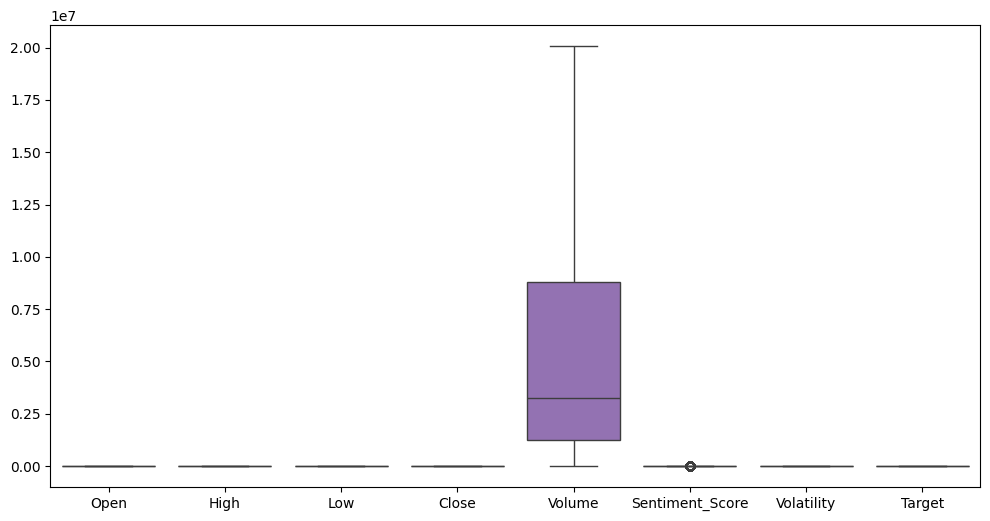

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(df)
plt.show()

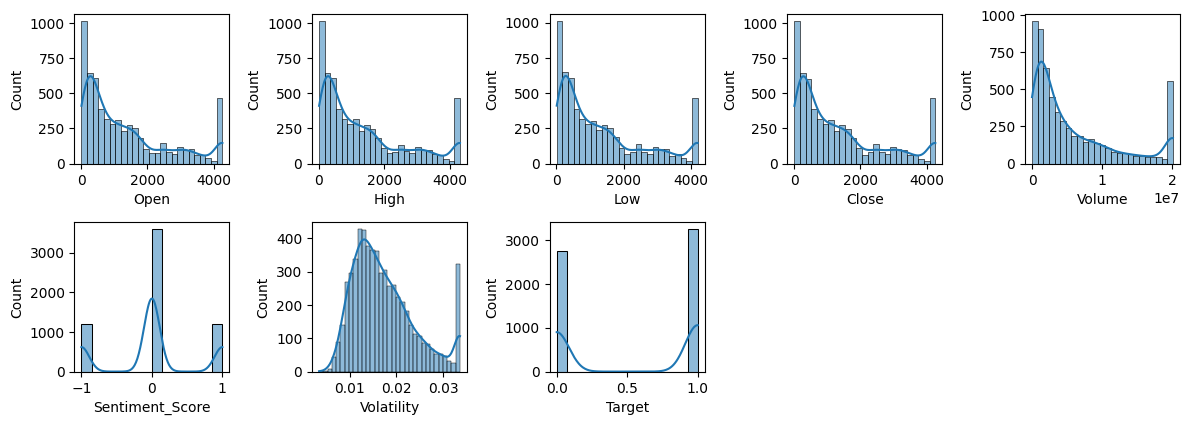

In [ ]:
from matplotlib import figure
numeric_column=df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 6))
plotnumber=1
for column in numeric_column:
    if plotnumber<=15:
        ax=plt.subplot(3,5,plotnumber)
        sns.histplot(df[column], kde=True)
        plt.xlabel(column,fontsize=10)
    plotnumber+=1
plt.tight_layout()
plt.show()

In [ ]:
numeric_column=df.select_dtypes(include=np.number)
numeric_column

,Open,High,Low,Close,Volume,Sentiment_Score,Volatility,Target
0,66.547213,68.372835,65.595632,68.090887,15536814.0,-1.0,0.027382,0
1,64.802560,64.943129,62.834586,63.122749,18656578.0,-1.0,0.027355,0
2,61.195763,62.305072,61.167500,62.163759,9157887.0,0.0,0.033498,1
3,63.051689,64.038560,62.115245,62.497030,10848470.0,0.0,0.029030,0
4,61.751109,62.276071,60.276908,60.478262,10785441.0,0.0,0.030508,1
...,...,...,...,...,...,...,...,...
5995,283.858080,285.650855,281.641989,283.360083,10839631.0,-1.0,0.015598,0
5996,280.253442,283.045991,276.912336,277.834897,11229827.0,0.0,0.015517,1
5997,292.167883,294.839833,289.321112,294.165612,15698820.0,0.0,0.016276,0
5998,296.070079,298.322514,291.264896,291.765437,13237746.0,0.0,0.015832,0


In [ ]:
skewness=numeric_column.skew().sort_values(ascending=False)
skewness

,0
Volume,1.198348
High,1.068015
Open,1.064406
Close,1.063436
Low,1.061697
Volatility,0.864053
Sentiment_Score,-0.000565
Target,-0.163922


In [ ]:
df.columns

Index(['Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Volume',
       'News_Headline', 'Sentiment_Score', 'Volatility', 'Target'],
      dtype='object')

In [ ]:
df['Volume']=np.log1p(df['Volume'])
df['Open']=np.log1p(df['Open'])
df['Low']=np.log1p(df['Low'])
df['High']=np.log1p(df['High'])
df['Close']=np.log1p(df['Close'])
df['Volatility']=np.log1p(df['Volatility'])
df['Sentiment_Score']=np.log1p(df['Sentiment_Score'])

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


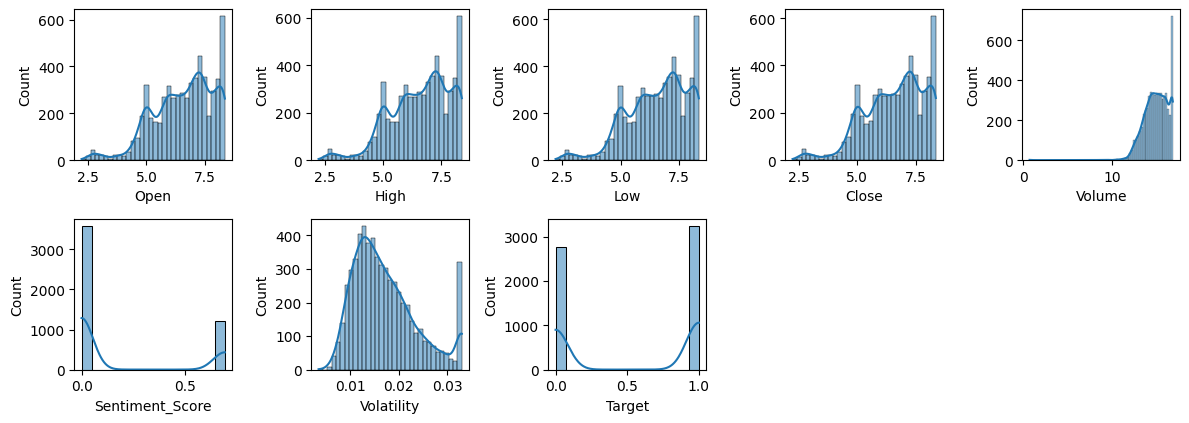

In [ ]:
from matplotlib import figure
numeric_column=df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 6))
plotnumber=1
for column in numeric_column:
    if plotnumber<=15:
        ax=plt.subplot(3,5,plotnumber)
        sns.histplot(df[column], kde=True)
        plt.xlabel(column,fontsize=10)
    plotnumber+=1
plt.tight_layout()
plt.show()

**ENCODING**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             6000 non-null   datetime64[ns]
 1   Symbol           6000 non-null   object        
 2   Open             6000 non-null   float64       
 3   High             6000 non-null   float64       
 4   Low              6000 non-null   float64       
 5   Close            6000 non-null   float64       
 6   Volume           6000 non-null   float64       
 7   News_Headline    6000 non-null   object        
 8   Sentiment_Score  6000 non-null   float64       
 9   Volatility       6000 non-null   float64       
 10  Target           6000 non-null   int64         
dtypes: datetime64[ns](1), float64(7), int64(1), object(2)
memory usage: 515.8+ KB


In [ ]:
df['Symbol'].unique()

array(['ADANIENT', 'ADANIPORTS', 'APOLLOHOSP', 'ASIANPAINT', 'AXISBANK',
       'BAJAJFINSV', 'BAJFINANCE', 'BHARTIARTL', 'BPCL', 'BRITANNIA',
       'CIPLA', 'COALINDIA', 'DRREDDY', 'EICHERMOT', 'GRASIM', 'HCLTECH',
       'HEROMOTOCO', 'HINDALCO', 'HINDUNILVR', 'INDUSINDBK', 'INFY',
       'ITC', 'JSWSTEEL', 'KOTAKBANK', 'LT', 'MARUTI', 'NESTLEIND',
       'NTPC', 'ONGC', 'RELIANCE', 'SBIN', 'SUNPHARMA', 'TATACONSUM',
       'TATASTEEL', 'TCS', 'TECHM', 'TITAN', 'ULTRACEMCO', 'WIPRO'],
      dtype=object)

In [ ]:
df["News_Headline"].unique()

array(["Australia Delays Decision On Adani's $15B Coal Project",
       'Robyn Lawley’s naked protest against Adani Group’s Carmichael Coal Mine approval. About three million cubic metres of material will be dredged from the seabed so freighters can dock.',
       'Adani Group plans to build Rs 12,500 crore power plant in Odisha',
       ...,
       'Verdence Capital Advisors LLC Makes New Investment in Wipro Limited (NYSE:WIT)',
       'Wipro (NYSE:WIT) Cut to “Hold” at StockNews.com',
       'Technical Call: Wipro - BUY'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Symbol'] = le.fit_transform(df['Symbol'])

In [ ]:
le = LabelEncoder()
df["News_Headline"] = le.fit_transform(df["News_Headline"])

In [ ]:
df['Symbol'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38])

In [ ]:
df["News_Headline"].unique()

array([ 202, 2013,   67, ..., 2422, 2455, 2228])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             6000 non-null   datetime64[ns]
 1   Symbol           6000 non-null   int64         
 2   Open             6000 non-null   float64       
 3   High             6000 non-null   float64       
 4   Low              6000 non-null   float64       
 5   Close            6000 non-null   float64       
 6   Volume           6000 non-null   float64       
 7   News_Headline    6000 non-null   int64         
 8   Sentiment_Score  6000 non-null   float64       
 9   Volatility       6000 non-null   float64       
 10  Target           6000 non-null   int64         
dtypes: datetime64[ns](1), float64(7), int64(3)
memory usage: 515.8 KB


In [ ]:
coormatrix = df.corr()
coormatrix

,Date,Symbol,Open,High,Low,Close,Volume,News_Headline,Sentiment_Score,Volatility,Target
Date,1.000000,0.070235,0.526452,0.526026,0.526503,0.526216,-0.014682,-0.034185,-0.022576,-0.179584,-0.031118
Symbol,0.070235,1.000000,0.003570,0.002224,0.005033,0.003425,0.065472,0.279039,-0.072153,-0.257894,0.013310
Open,0.526452,0.003570,1.000000,0.999941,0.999937,0.999900,-0.534395,-0.030306,-0.040909,-0.270111,-0.036446
High,0.526026,0.002224,0.999941,1.000000,0.999907,0.999958,-0.532792,-0.030384,-0.039855,-0.267114,-0.036423
Low,0.526503,0.005033,0.999937,0.999907,1.000000,0.999944,-0.535744,-0.029908,-0.041604,-0.273241,-0.036634
Close,0.526216,0.003425,0.999900,0.999958,0.999944,1.000000,-0.533980,-0.030079,-0.040215,-0.269733,-0.036612
Volume,-0.014682,0.065472,-0.534395,-0.532792,-0.535744,-0.533980,1.000000,0.053046,0.075487,0.365041,0.009504
News_Headline,-0.034185,0.279039,-0.030306,-0.030384,-0.029908,-0.030079,0.053046,1.000000,-0.002598,-0.044764,0.011278
Sentiment_Score,-0.022576,-0.072153,-0.040909,-0.039855,-0.041604,-0.040215,0.075487,-0.002598,1.000000,0.118681,0.117677
Volatility,-0.179584,-0.257894,-0.270111,-0.267114,-0.273241,-0.269733,0.365041,-0.044764,0.118681,1.000000,0.014554


<Axes: >

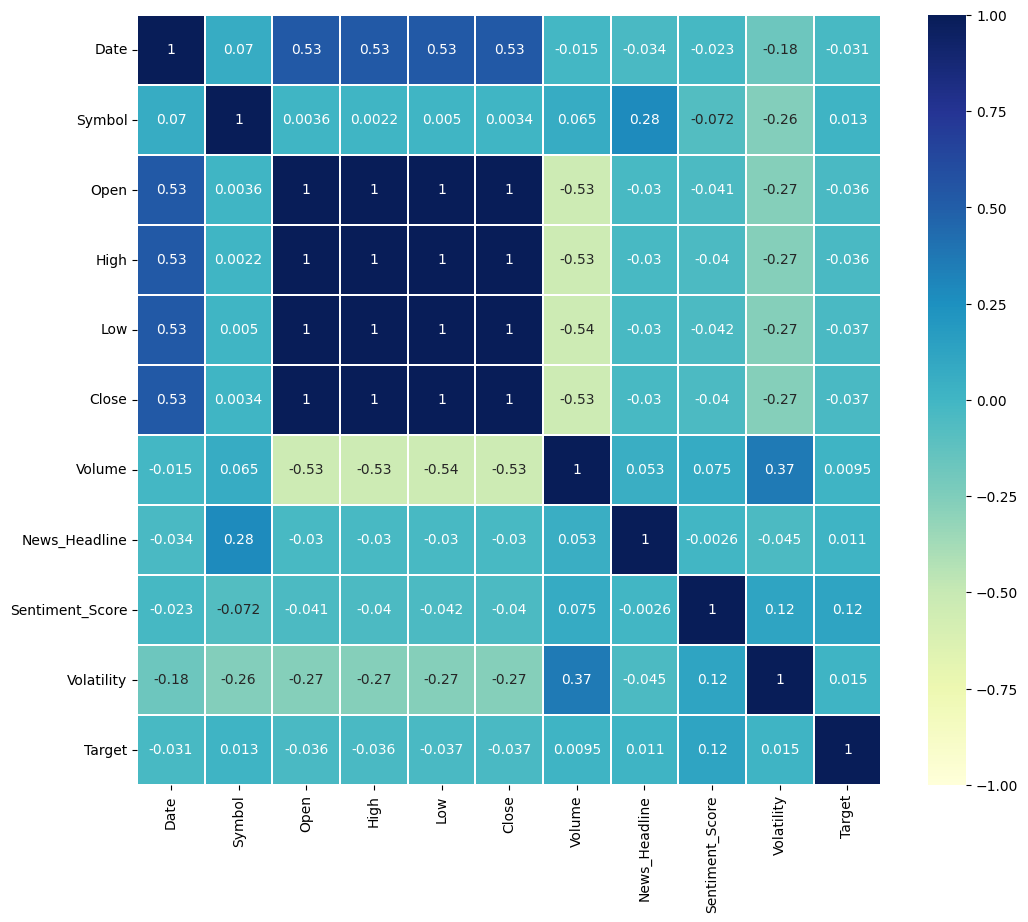

In [ ]:
coormatrix=df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(coormatrix,vmin=-1,vmax=1,annot=True,linewidths=.2,cmap='YlGnBu')

**SELECT THE BEST FEATURES**

In [ ]:
# Ensure Date is datetime type and sort for correct Next_Return calculation
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# Create next-day return
df["Next_Return"] = (df.groupby("Symbol")["Close"].shift(-1) / df["Close"]) - 1

# Remove rows where next-day return is unavailable
df = df.dropna(subset=["Next_Return"]).reset_index(drop=True)

# Define features (x) and target (y)
x = df.drop(columns=['Target', 'Date', 'Next_Return'])
y = df['Next_Return']

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression

# Ensure x_numeric is defined from the current x
x_numeric = x.select_dtypes(include=np.number)

# Handle infinite values before SelectKBest (Sentiment_Score could have -inf)
x_numeric = x_numeric.replace([np.inf, -np.inf], np.nan).fillna(0)

# Run SelectKBest
selector = SelectKBest(mutual_info_regression, k=7)
selector.fit(x_numeric, y)

# Get selected feature names
selected_features = x_numeric.columns[selector.get_support()]
print("Selected Features:", list(selected_features))

Selected Features: ['Symbol', 'Open', 'High', 'Low', 'Close', 'Volume', 'News_Headline']


SCALING

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Filter x_numeric to include only the selected numeric features and handle inf/NaN values
x_processed = x_numeric[selected_features].replace([np.inf, -np.inf], np.nan).fillna(0)

# Initialize and apply MinMaxScaler
normalisation = MinMaxScaler()
x_scaled_array = normalisation.fit_transform(x_processed);

# Convert scaled array back to DataFrame with original feature names
x = pd.DataFrame(x_scaled_array, columns=selected_features)

In [ ]:
x.describe()

,Symbol,Open,High,Low,Close,Volume,News_Headline
count,5961.000000,5961.000000,5961.000000,5961.000000,5961.000000,5961.000000,5961.000000
mean,0.394732,0.710826,0.710532,0.710802,0.710711,0.883281,0.471353
std,0.299597,0.206379,0.206261,0.206552,0.206442,0.082330,0.274366
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.131579,0.574862,0.574960,0.574249,0.574409,0.828271,0.247097
50%,0.289474,0.742586,0.742039,0.741795,0.742242,0.887754,0.457349
75%,0.684211,0.866576,0.866737,0.866719,0.867020,0.948764,0.689628
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (4768, 7)
x_test shape: (1193, 7)
y_train shape: (4768,)
y_test shape: (1193,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(x_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(x_test)

print("Predicted values:")
print(y_pred[:10])

Predicted values:
[ 1.47049504e-03  7.88868078e-03 -9.18620095e-03  4.15033237e-03
 -3.06909601e-03  2.02272960e-03  1.98710443e-05  1.37307169e-03
 -7.17541963e-03  4.04030837e-02]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.0074813958279476706
MSE: 0.0003211916875790785
RMSE: 0.017921821547462146
R² Score: 0.051251619008301


In [ ]:
X = df.drop(columns=["Target", "Next_Return", "Date"], errors="ignore")
y = df["Target"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

print(le.classes_)

[0 1]


In [ ]:
import numpy as np

X = X.select_dtypes(include=np.number)

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (4768, 9)
Testing: (1193, 9)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5565800502933781

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.19      0.28       541
           1       0.56      0.86      0.68       652

    accuracy                           0.56      1193
   macro avg       0.55      0.53      0.48      1193
weighted avg       0.55      0.56      0.50      1193


Confusion Matrix:
[[101 440]
 [ 89 563]]


Regression Hyperparameter Tuning